In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from sc_flow.trainer._trainer import FlowTrainer
import matplotlib.pyplot as plt
import optax
from sc_flow.backends.jax.coupling import ot_linear_coupling
from sc_flow.backends.jax.methods import BaseMethod
from sc_flow.backends.jax.nn._vf import MLPUnconditionalVF
from sc_flow.backends.jax.probability_paths import LinearGaussianProbabilityPath
import jax
import jax.numpy as jnp
# from sc_flow.backends.torch.methods import BaseMethod

In [ ]:
def dummy_time_sampler(rng, n):
    """Dummy time sampler that generates uniform random time points between 0 and 1."""
    return jax.random.uniform(rng, shape=(n,), minval=0.0, maxval=1.0)

In [5]:
vf_rng = jax.random.PRNGKey(0)
batch_size = 512
time_sampler = dummy_time_sampler

In [ ]:
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)
probability_path = LinearGaussianProbabilityPath(sigma=0.01)
match_fn = ot_linear_coupling
time_sampler = dummy_time_sampler
target_dim = 2
opt = optax.adam(1e-3)


method = BaseMethod(
    vf=vf,
    probability_path=probability_path,
    time_sampler=time_sampler,
    match_fn=match_fn,
    target_dim=target_dim,
    generate_from_noise=False,
    control_key=None,
    optimizer=opt,
    condition_dict={"drug": jnp.ones((batch_size, 1))},
    rng=vf_rng,
)

In [7]:
trainer = FlowTrainer(
    method=method,
    require_prng=True,
)

In [8]:
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import scanpy as sc


class BaseDummyDataset(ABC):
    """
    Abstract base class for all dummy dataset generators.

    Attributes
    ----------
    random_state : int
        Random seed for reproducibility across all dataset types

    dataset_name : str
        Identifier for the dataset type (e.g., 'blobs', 'moons')
    """

    def __init__(self, random_state: int, n_samples: int, n_features: int, **kwargs):
        """
        Initialize the base dataset generator.

        Parameters
        ----------
        random_state : int, optional (default=42)
            Seed for random number generation to ensure reproducibility
        """
        self.dataset_name = self._get_dataset_name()
        self.random_state = random_state
        self._validate_parameters(random_state, n_samples, n_features, **kwargs)
        self.adata = self._generate(random_state, n_samples, n_features, **kwargs)

    def _create_anndata(
        self, X: np.ndarray, y: np.ndarray | None = None, additional_obs: dict[str, np.ndarray] | None = None
    ) -> sc.AnnData:
        """
        Convert raw numpy arrays into AnnData format with standardized structure.

        Parameters
        ----------
        X : np.ndarray, shape (n_observations, n_features)
            Data matrix where each row is an observation (e.g., a cell)
            and each column is a feature (e.g., a gene or coordinate)

        y : np.ndarray, optional, shape (n_observations,)
            Cluster labels or class assignments for each observation

        additional_obs : dict, optional
            Additional observation-level annotations to store in .obs

        Returns
        -------
        adata : sc.AnnData
            Annotated data object with standardized structure
        """
        # Step 1: Create the core AnnData structure
        adata = sc.AnnData(X=X)

        # Step 2: Create standardized observation names
        n_obs = X.shape[0]
        adata.obs_names = [f"cell_{i}" for i in range(n_obs)]

        # Step 3: Create standardized variable (feature) names
        n_vars = X.shape[1]
        adata.var_names = [f"feature_{i}" for i in range(n_vars)]

        # Step 4: Add cluster labels if provided
        # Labels are stored as strings for categorical data
        if y is not None:
            adata.obs["labels"] = y.astype(str)
            adata.obs["labels"] = adata.obs["labels"].astype("category")

        # Step 5: Add any additional observation-level data
        if additional_obs is not None:
            for key, values in additional_obs.items():
                adata.obs[key] = values

        # Step 6: Store metadata about the dataset
        adata.uns["dataset_info"] = self._create_metadata(X)

        return adata

    def _create_metadata(self, X: np.ndarray) -> dict[str, Any]:
        """
        Create standardized metadata dictionary for the dataset.

        Parameters
        ----------
        X : np.ndarray
            The data matrix to extract shape information from

        Returns
        -------
        metadata : dict
            Dictionary containing dataset information
        """
        return {
            "name": self.dataset_name,
            "n_observations": X.shape[0],
            "n_features": X.shape[1],
            "random_state": self.random_state,
            "generator": self.__class__.__name__,
        }

    def _validate_parameters(self, random_state, n_samples: int, n_features: int, **kwargs) -> None:
        """
        Validate common parameters to prevent errors.

        Parameters
        ----------
        n_samples : int
            Number of observations to generate

        n_features : int
            Number of features (dimensions) for each observation

        Raises
        ------
        ValueError : If parameters are invalid
        """
        if not isinstance(n_samples, int):
            raise TypeError(f"n_samples must be an integer, got {type(n_samples)}")

        if not isinstance(n_features, int):
            raise TypeError(f"n_features must be an integer, got {type(n_features)}")

        if not isinstance(random_state, int):
            raise TypeError(f"random_state must be an integer, got {type(random_state)}")

        if n_samples <= 0:
            raise ValueError(f"n_samples must be positive, got {n_samples}")

        if n_features <= 0:
            raise ValueError(f"n_features must be positive, got {n_features}")

        self._validate_additional_parameters(**kwargs)

    @abstractmethod
    def _validate_additional_parameters(self, **kwargs) -> None:
        """Validate dataset-specific parameters."""
        raise NotImplementedError

    @abstractmethod
    def _get_dataset_name(self) -> str:
        """
        Return the name identifier for this dataset type.

        This is an abstract method - each child class must implement it.
        Example: BlobsDataset would return "blobs"

        Returns
        -------
        str : Name of the dataset
        """
        raise NotImplementedError

    @abstractmethod
    def _generate(self, **kwargs) -> sc.AnnData:
        """
        Generate the dataset with specific parameters.

        This is an abstract method - each child class must implement its own
        generation logic using sklearn or custom algorithms.

        Parameters
        ----------
        **kwargs : dict
            Dataset-specific parameters (e.g., n_samples, noise level)

        Returns
        -------
        adata : sc.AnnData
            Generated dataset wrapped in AnnData format
        """
        raise NotImplementedError

In [9]:
import scanpy as sc
from sklearn import datasets


class MoonsDataset(BaseDummyDataset):
    """
    Generate two interleaving half-circles (moons).

    Parameters
    ----------
    random_state : int, optional (default=42)
        Seed for random number generation to ensure reproducibility

    n_samples : int, optional (default=1000)
        Total number of samples to generate

    noise : float, optional (default=0.0)
        Standard deviation of Gaussian noise added to the data

    shuffle : bool, optional (default=True)
        Whether to shuffle the samples after generation
    """

    def __init__(self, random_state: int = 42, n_samples: int = 1000, noise: float = 0.0, shuffle: bool = True):
        """Initialization"""
        super().__init__(random_state, n_samples, n_features=2, noise=noise, shuffle=shuffle)

    def _get_dataset_name(self) -> str:
        """Return identifier for this dataset type."""
        return "moons"

    def _validate_additional_parameters(self, **kwargs):
        """Validate dataset-specific parameters."""
        noise = kwargs["noise"]
        shuffle = kwargs["shuffle"]

        if not isinstance(noise, int | float):
            raise TypeError(f"noise must be a number, got {type(noise)}")

        if noise < 0:
            raise ValueError(f"noise must be non-negative, got {noise}")

        if not isinstance(shuffle, bool):
            raise TypeError(f"shuffle must be a boolean, got {type(shuffle)}")

    def _generate(self, random_state, n_samples, n_features, noise, shuffle) -> sc.AnnData:
        """
        Generate interleaving half-circles (moons) dataset.

        Returns
        -------
        adata : sc.AnnData
            Dataset with two interleaving half-circles labeled as class 0 and 1
        """
        # Step 1: Generate moons using sklearn
        X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state, shuffle=shuffle)

        # Step 2: Wrap in AnnData format
        adata = self._create_anndata(X, y)

        # Step 3: Add moons-specific metadata
        adata.uns["dataset_info"]["noise"] = noise
        adata.uns["dataset_info"]["shuffle"] = shuffle

        return adata

In [10]:
adata = MoonsDataset()._generate(n_samples=10_000, random_state=42, n_features=2, noise=0.1, shuffle=False)

In [ ]:
class DummyTrainLoader:
    """Dummy training data loader for the moons dataset."""

    def __init__(self, adata, batch_size):
        self.adata = adata
        self.batch_size = batch_size
        self.top_moon = adata[adata.obs.labels == "1"].copy()
        self.bottom_moon = adata[adata.obs.labels == "0"].copy()

    def sample(self, _):
        """Sample a batch of data for training."""
        return {
            "src_cell_data": jnp.array(
                self.top_moon.X[np.random.choice(np.arange(1, self.top_moon.shape[0]), size=self.batch_size), :]
            ),
            "tgt_cell_data": jnp.array(
                self.bottom_moon.X[np.random.choice(np.arange(1, self.bottom_moon.shape[0]), size=self.batch_size), :]
            ),
        }

In [12]:
train_loader = DummyTrainLoader(adata=adata, batch_size=512)

In [13]:
train_loader_key = jax.random.PRNGKey(0)

In [14]:
data = train_loader.sample(None)

In [15]:
data

{'src_cell_data': Array([[ 1.5196956 , -0.31296596],
        [ 2.0942316 ,  0.38331145],
        [ 1.6427084 , -0.33133367],
        ...,
        [ 1.8581296 , -0.02182847],
        [ 0.30593315, -0.4149637 ],
        [ 0.6125537 , -0.41116506]], dtype=float32),
 'tgt_cell_data': Array([[ 0.12626705,  0.9617264 ],
        [-0.5194687 ,  0.74503887],
        [-0.37438977,  0.8159863 ],
        ...,
        [-0.8045216 ,  0.4564526 ],
        [-0.9270642 , -0.10516933],
        [ 0.6722993 ,  0.5814503 ]], dtype=float32)}

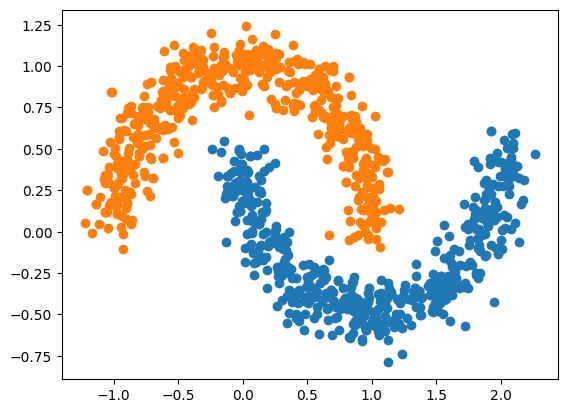

In [16]:
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])

In [17]:
vf

MLPUnconditionalVF(
    # attributes
    state_dim = 2
    encode_state = True
    encode_time = True
    time_features_id = 'torch-cfm'
    time_features_fn = None
    num_time_features = 256
    max_period = 1000
    time_features_kwargs = {}
    state_encoder_output_dim = 32
    time_encoder_output_dim = 16
    state_encoder_mlp_kwargs = {'hidden_dims': (32,)}
    time_encoder_mlp_kwargs = {'hidden_dims': (16,)}
    vf_decoder_mlp_kwargs = {'hidden_dims': (64, 64)}
    conditioning_id = 'concat'
    conditioning_fn = None
    conditioning_kwargs = None
    condition_encoder_input_layers = None
    condition_encoder_output_dim = 32
    condition_encoder_pooling_mode = 'mean'
    condition_encoder_pooling_kwargs = {}
    condition_encoder_output_layers_kwargs = None
    source_encoder_mlp_kwargs = None
    source_encoder_output_dim = 16
)

In [19]:
trainer.fit(train_dataloader=train_loader, num_iterations=1_000, valid_freq=10000, prng=train_loader_key)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [07:25<00:00,  2.25it/s]


In [20]:
print(jax.devices())

[CpuDevice(id=0)]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

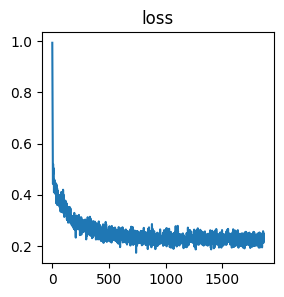

In [21]:
trainer.plot_training_logs()

In [22]:
x = jnp.array(np.random.randn(512, 2))

In [23]:
preds = trainer._method.predict(data["src_cell_data"])

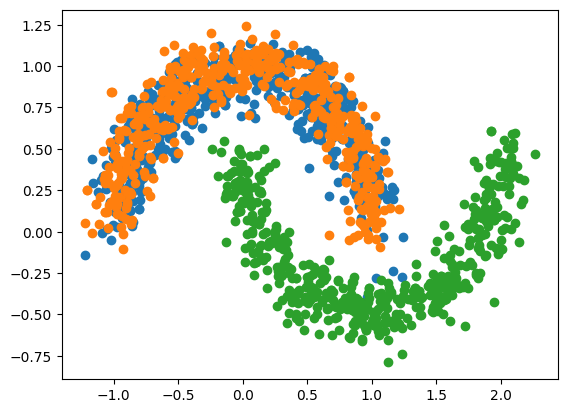

In [25]:
plt.scatter(preds[:, 0], preds[:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])